Import Libraries

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

Load Dataset

In [43]:
df = pd.read_csv("Project 7 Car Price Prediction.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


Exploratory Data Analysis (EDA)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


Shape of Dataset

In [45]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 4340
Columns : 8


Missing Values

In [46]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


Statistical Summary

In [47]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


Duplicate Values

In [48]:
print("Duplicate Rows =", df.duplicated().sum())

Duplicate Rows = 763


Remove duplicates (if any)

In [49]:
df = df.drop_duplicates()

Check Data Types

In [50]:
df.dtypes

,0
name,object
year,int64
selling_price,int64
km_driven,int64
fuel,object
seller_type,object
transmission,object
owner,object


Unique Values

In [51]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-----------------------")

name
['Maruti 800 AC' 'Maruti Wagon R LXI Minor' 'Hyundai Verna 1.6 SX' ...
 'Mahindra Verito 1.5 D6 BSIII'
 'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV'
 'Hyundai i20 Magna 1.4 CRDi']
-----------------------
year
[2007 2012 2017 2014 2016 2015 2018 2019 2013 2011 2010 2009 2006 1996
 2005 2008 2004 1998 2003 2002 2020 2000 1999 2001 1995 1997 1992]
-----------------------
selling_price
[  60000  135000  600000  250000  450000  140000  550000  240000  850000
  365000  260000 1650000  585000 1195000  390000 1964999 1425000  975000
 1190000  930000  525000 1735000 1375000  900000 1300000 1400000  229999
 1550000 1250000  625000 1050000  560000  290000  275000  411000  150000
  500000  100000  725000  401000  750000  310000  665000  465000  160000
  675000  300000   70000  151000  280000  350000  570000  125000  130000
  925000  200000  248000   80000  650000  495000  371000 1025000 8150000
  325000 1470000 2800000  210000 1150000 4500000 2750000 1975000  175000
 2500000  628000  399000

Correlation Heatmap

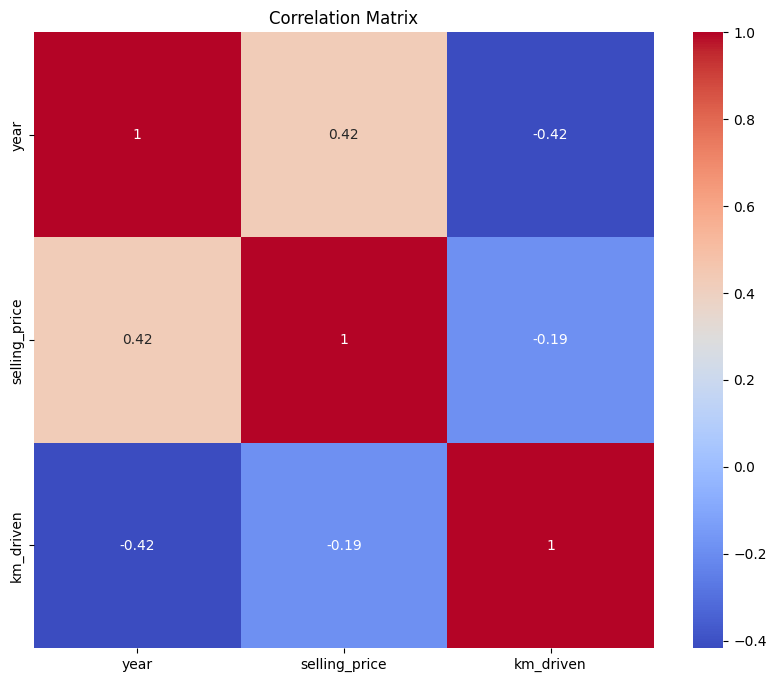

In [52]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

Selling Price Distribution

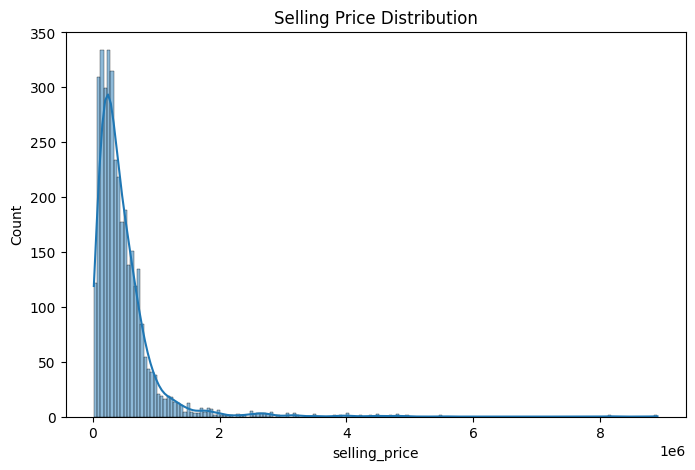

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(df["selling_price"],
             kde=True)

plt.title("Selling Price Distribution")
plt.show()

Year Distribution

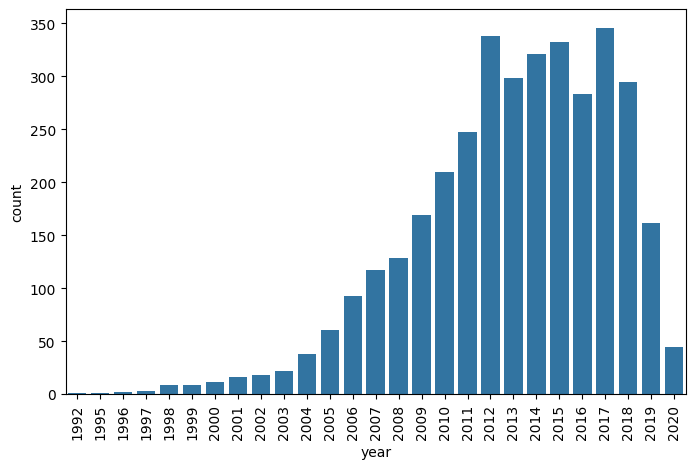

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(x="year", data=df)

plt.xticks(rotation=90)

plt.show()

Fuel Type Count

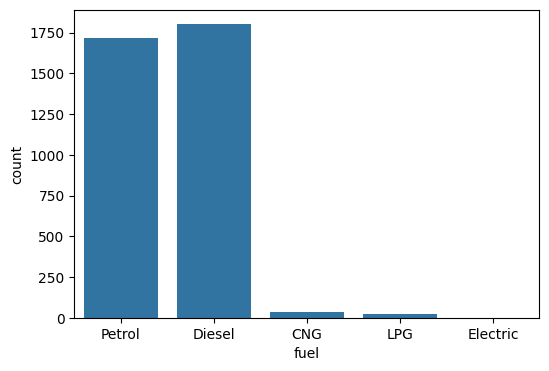

In [55]:
plt.figure(figsize=(6,4))

sns.countplot(x="fuel", data=df)

plt.show()

Transmission Type

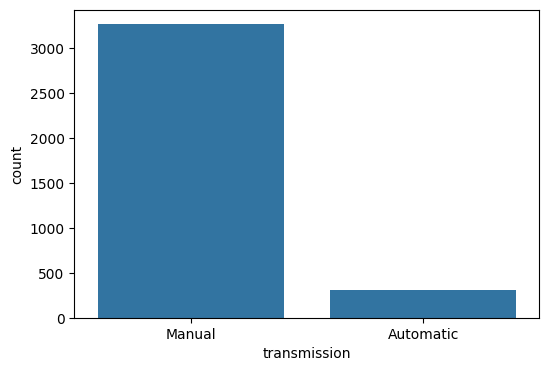

In [56]:
plt.figure(figsize=(6,4))

sns.countplot(x="transmission", data=df)

plt.show()

Owner Type

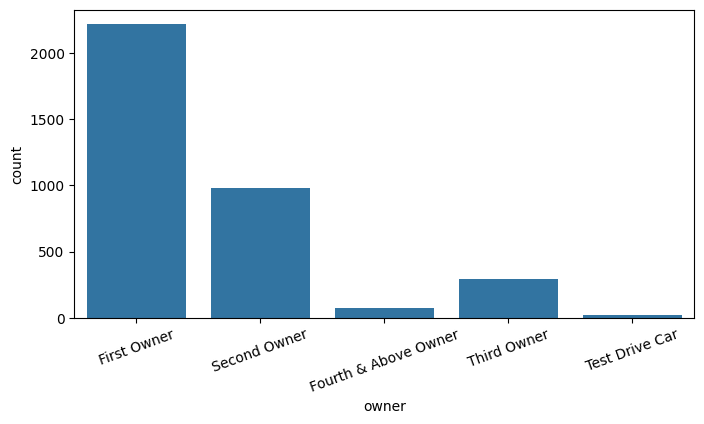

In [57]:
plt.figure(figsize=(8,4))

sns.countplot(x="owner", data=df)

plt.xticks(rotation=20)

plt.show()

Selling Price vs Year

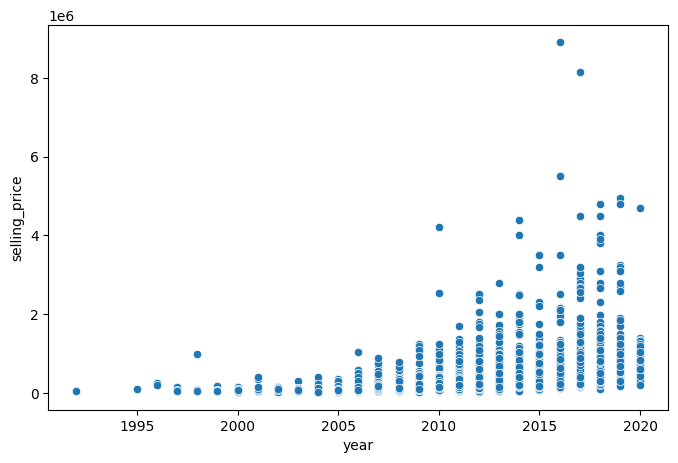

In [58]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="year",
    y="selling_price",
    data=df
)

plt.show()

KM Driven vs Selling Price

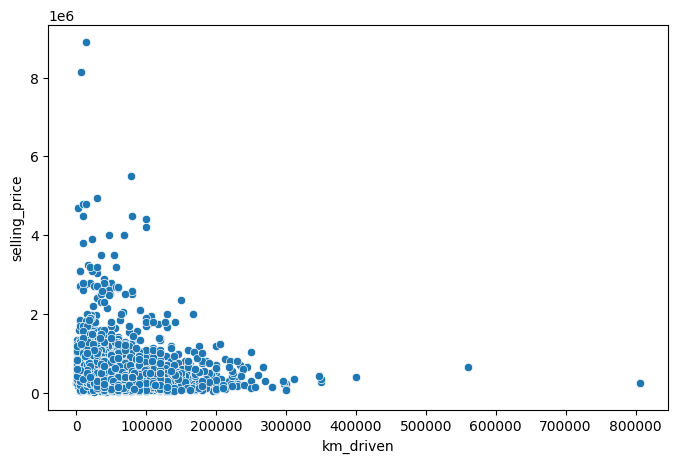

In [59]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="km_driven",
    y="selling_price",
    data=df
)

plt.show()

Boxplot for Outliers

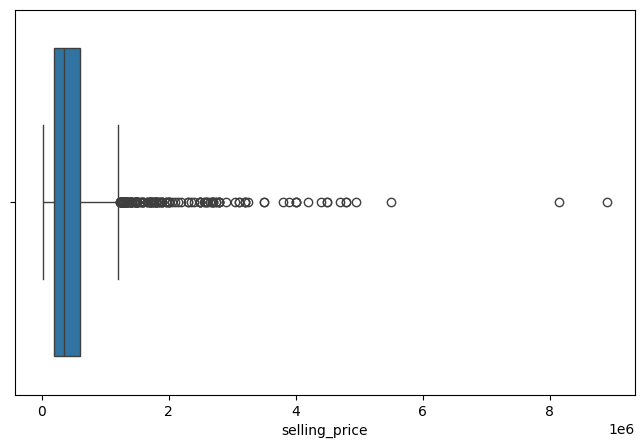

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["selling_price"])

plt.show()

Data Preprocessing
Label Encoding

In [61]:
le = LabelEncoder()

categorical_columns = [
    "name",
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

Features and Target

In [62]:
X = df.drop("selling_price", axis=1)

y = df["selling_price"]

Step 6: Feature Scaling (Optional)

In [63]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Step 7: Train-Test Split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

Step 8: Train Linear Regression Model

In [65]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Step 9: Prediction

In [66]:
y_pred = model.predict(X_test)

Step 10: Model Evaluation
R² Score

In [67]:
print("R2 Score =", r2_score(y_test, y_pred))

R2 Score = 0.3845301161683755


MAE

In [68]:
print("MAE =", mean_absolute_error(y_test, y_pred))

MAE = 214911.47567332283


MSE

In [69]:
print("MSE =", mean_squared_error(y_test, y_pred))

MSE = 198263378271.34103


RMSE

In [70]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE =", rmse)

RMSE = 445267.7601975479


Step 11: Model Coefficients

In [71]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef

,Feature,Coefficient
0,name,-16847.618922
1,year,150088.802630
2,km_driven,-29476.566524
3,fuel,-122492.572191
4,seller_type,-12448.157469
5,transmission,-220755.712674
6,owner,-21351.888001


Step 12: Actual vs Predicted Plot

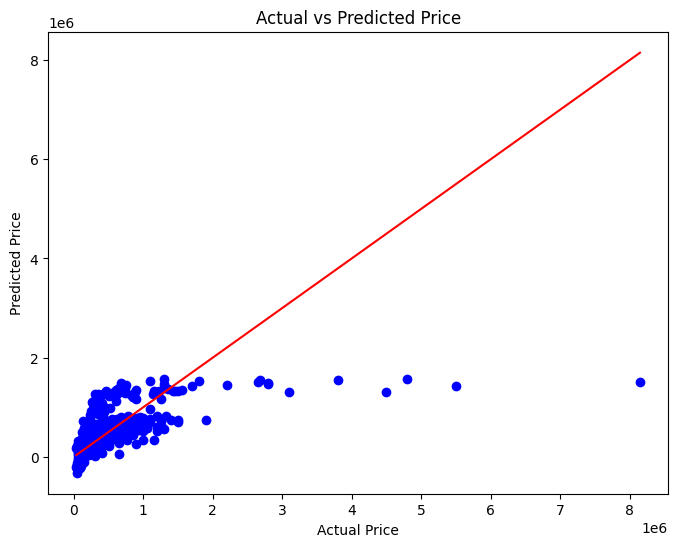

In [72]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    color='blue'
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

Step 13: Residual Plot

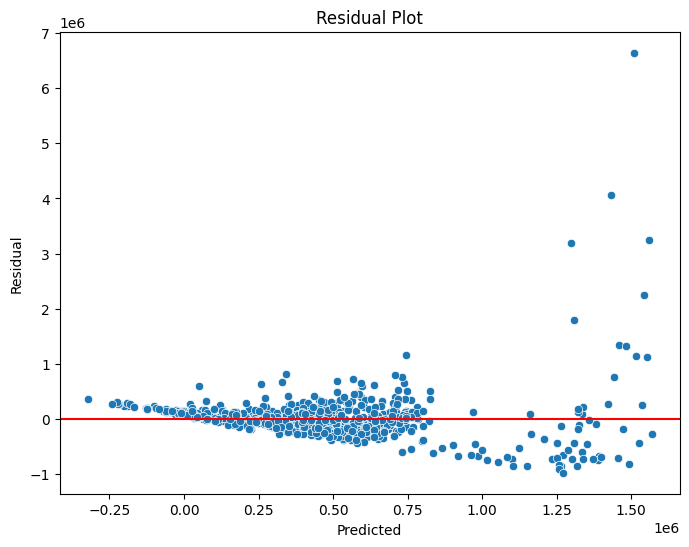

In [73]:
residual = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residual
)

plt.axhline(0,
            color='red')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

Step 14: Predict New Car Price

In [74]:
sample = X_test[0].reshape(1,-1)

prediction = model.predict(sample)

print("Predicted Price =", prediction[0])

Predicted Price = 490229.69328984816


Step 15: Final Model Accuracy

In [75]:
print("Model Accuracy (R² Score):")

print(round(r2_score(y_test, y_pred)*100,2),"%")

Model Accuracy (R² Score):
38.45 %


1. Remove Outliers (Highly Recommended)

In [76]:
# Remove outliers using IQR

Q1 = df['selling_price'].quantile(0.25)
Q3 = df['selling_price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['selling_price'] >= lower) &
        (df['selling_price'] <= upper)]

2. Feature Engineering

Create a new feature Car Age.

In [77]:
current_year = 2024

df['car_age'] = current_year - df['year']

df.drop('year', axis=1, inplace=True)

3. One-Hot Encoding (Better than Label Encoding)

Replace

In [78]:
df = pd.get_dummies(df,
                    columns=['fuel',
                             'seller_type',
                             'transmission',
                             'owner'],
                    drop_first=True)

4. Remove the Name Column
The car name contains many unique values and often hurts Linear Regression.

In [79]:
df.drop('name', axis=1, inplace=True)

Log Transform the Target - Car prices are heavily skewed.

In [80]:
import numpy as np

df['selling_price'] = np.log1p(df['selling_price'])

6. Standard Scaling

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

Polynomial Features

In [82]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2,
                          include_bias=False)

X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Cross Validation

In [83]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model,
                         X,
                         y,
                         cv=10,
                         scoring='r2')

print(scores)
print("Average R²:", scores.mean())

[0.41522127 0.47833058 0.46012952 0.48420359 0.45330566 0.42384845
 0.33441812 0.4466977  0.27947665 0.34796032]
Average R²: 0.4123591848121772


In [84]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test, y_pred))

0.48486524076389925


In [92]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

# Model
lr = LinearRegression()

# Parameters to tune
param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

# Grid Search
grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

# Best model
best_model = grid.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best Parameters: {'fit_intercept': True, 'positive': False}
Best Cross Validation Score: 0.5341020993583574
R2 Score: 0.46954484017396014
MAE: 185641.50443328868
RMSE: 413373.0761015738


In [93]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 50, 100],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag']
}

grid = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Test R2:", r2_score(y_test, y_pred))

Best Parameters: {'alpha': 50, 'solver': 'svd'}
Best CV Score: 0.5343690055027783
Test R2: 0.4689415216468913


In [94]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best CV Score:")
print(grid.best_score_)

best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

print("Test R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score:
0.6420698059010793
Test R²: 0.49205653626243073
MAE: 146861.57305943916
RMSE: 404506.52883390273


XGBoost (Best Performance)

In [90]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test, y_pred))

0.46151769161224365
